In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv('tickets_train.csv')

In [ ]:
df.head()

,ticket_id,created_at,channel,order_value,text,category
0,T100001,2025-08-07 05:44:48,chat,18.64,Ugh dasher asked me to cancel the order second...,dasher_feedback
1,T100002,2025-08-03 13:37:34,chat,35.57,They forogt my dumplings again. also card got ...,missing_item
2,T100003,2025-08-28 13:52:23,chat,41.00,"hey supoprt, no side of rice in my delivery th...",missing_item
3,T100004,2025-09-19 11:16:39,chat,92.04,UGH COMPLETELY WRONG ORDER DELIVERED TO ME SEC...,wrong_order
4,T100005,2025-09-12 03:47:12,email,96.12,"Where is my order, it said it would arrive 47 ...",late_delivery


In [ ]:
df.isnull().sum()

,0
ticket_id,0
created_at,0
channel,0
order_value,0
text,0
category,0


In [ ]:
df['category'].value_counts()

,count
category,
late_delivery,833
missing_item,638
payment_issue,467
dasher_feedback,388
account_access,341
wrong_order,333


In [ ]:
def preprocess(df):
  # 1. Convert text to lowercase
  df['text'] = df['text'].str.lower()

  # 2. Remove order numbers (e.g., 'order #123456', 'order 654321')
  df['text'] = df['text'].str.replace(r'order\s*#?\s*\d+', '', regex=True)

  # 3. Remove prices (e.g., '$75', '$75.50')
  df['text'] = df['text'].str.replace(r'\$\d+(?:\.\d+)?', '', regex=True)

  # 4. Clean up extra leftover whitespace and punctuation symbols
  df['text'] = df['text'].str.replace(r'[^\w\s]', '', regex=True)  # remove punctuation
  df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True).str.strip()

  return df

In [ ]:
# data = {'text': ['Order #123456 missing item, cost $75.50', 'order 987654 delivery was late']}
# df = pd.DataFrame(data)

# # Apply preprocessing
# df = preprocess(df)
# print('Cleaned Text:\n', df['text'])

In [ ]:
preprocess(df)

,ticket_id,created_at,channel,order_value,text,category
0,T100001,2025-08-07 05:44:48,chat,18.64,ugh dasher asked me to cancel the order second...,dasher_feedback
1,T100002,2025-08-03 13:37:34,chat,35.57,they forogt my dumplings again also card got d...,missing_item
2,T100003,2025-08-28 13:52:23,chat,41.00,hey supoprt no side of rice in my delivery thanks,missing_item
3,T100004,2025-09-19 11:16:39,chat,92.04,ugh completely wrong order delivered to me sec...,wrong_order
4,T100005,2025-09-12 03:47:12,email,96.12,where is my order it said it would arrive 47 m...,late_delivery
...,...,...,...,...,...,...
2995,T103995,2025-08-22 13:50:07,email,75.89,driver ignored the drop off instructions,dasher_feedback
2996,T103997,2025-09-11 11:01:12,email,106.96,hi card got declined but the money still left ...,payment_issue
2997,T103998,2025-09-24 21:35:47,email,86.17,urgent promo code did not apply at checkout ca...,payment_issue
2998,T103999,2025-08-23 02:24:36,chat,93.91,order is 52 minutes late and still not here pe...,late_delivery


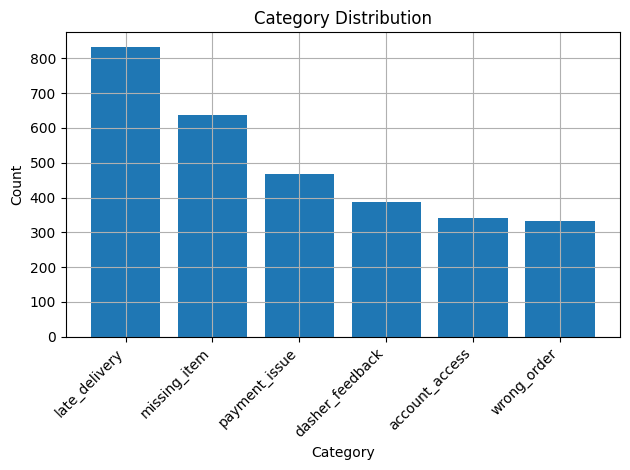

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.bar(df['category'].value_counts().index,df['category'].value_counts())
plt.title('Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

In [ ]:
X=df.drop(['ticket_id','created_at','channel','order_value','category'],axis=1)
y=df['category']

In [ ]:
print(X)

                                                   text
0     ugh dasher asked me to cancel the order second...
1     they forogt my dumplings again also card got d...
2     hey supoprt no side of rice in my delivery thanks
3     ugh completely wrong order delivered to me sec...
4     where is my order it said it would arrive 47 m...
...                                                 ...
2995           driver ignored the drop off instructions
2996  hi card got declined but the money still left ...
2997  urgent promo code did not apply at checkout ca...
2998  order is 52 minutes late and still not here pe...
2999  hi estimated arrival went from 55 to 68 minute...

[3000 rows x 1 columns]


In [ ]:
print(y)

0       dasher_feedback
1          missing_item
2          missing_item
3           wrong_order
4         late_delivery
             ...       
2995    dasher_feedback
2996      payment_issue
2997      payment_issue
2998      late_delivery
2999      late_delivery
Name: category, Length: 3000, dtype: object


In [ ]:
import nltk
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer=TfidfVectorizer(
    max_features=50000,
    stop_words='english',
    ngram_range=(1,2)
)

In [ ]:
X=vectorizer.fit_transform(df['text'])

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()
y = encoder.fit_transform(df['category'])

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y)

In [ ]:
from sklearn.naive_bayes import MultinomialNB,ComplementNB
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier


In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
models={
    'MultinomialNB': MultinomialNB(),
    'ComplementNB': ComplementNB(),
    'DecisionTree':DecisionTreeClassifier(),
    'RandomForest':RandomForestClassifier(),
    'GradientBoosting':GradientBoostingClassifier(),
    'XGBClassifier':XGBClassifier()
}


for n,m in models.items():
  print(f'Training {n}...')
  m.fit(X_train,y_train)
  y_pred=m.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  print(cm)
  print(classification_report(y_test,y_pred))


Training MultinomialNB...
[[ 62   2   1   0   1   2]
 [  1  65   6   1   3   2]
 [  1   0 160   2   3   1]
 [  1   4   4 115   1   2]
 [  2   2   3   0  86   0]
 [  3   0   3   5   4  52]]
              precision    recall  f1-score   support

           0       0.89      0.91      0.90        68
           1       0.89      0.83      0.86        78
           2       0.90      0.96      0.93       167
           3       0.93      0.91      0.92       127
           4       0.88      0.92      0.90        93
           5       0.88      0.78      0.83        67

    accuracy                           0.90       600
   macro avg       0.90      0.88      0.89       600
weighted avg       0.90      0.90      0.90       600

Training ComplementNB...
[[ 64   1   1   0   1   1]
 [  3  64   5   1   3   2]
 [  1   0 159   2   3   2]
 [  2   4   4 113   1   3]
 [  2   2   4   0  85   0]
 [  3   1   2   4   4  53]]
              precision    recall  f1-score   support

           0       0.85  

In [ ]:
final_model=MultinomialNB()
final_model.fit(X_train,y_train)

MultinomialNB()

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

In [ ]:
user_input = input("Enter the message: ")

X_new = vectorizer.transform([user_input])

prediction = final_model.predict(X_new)[0]
probabilities = final_model.predict_proba(X_new)[0]

category = encoder.inverse_transform([prediction])[0]
confidence = probabilities[prediction]

print("Predicted Category:", category)
print(f"Confidence: {confidence:.2%}")

Enter the message: HI, RECEIVED GARLIC BREAD INSTEAD OF THE DUMPLINGS
Predicted Category: wrong_order
Confidence: 44.41%


In [ ]:
test_df=pd.read_csv('tickets_test.csv')
X_test_text=test_df['text']
X_test_vectorized=vectorizer.transform(X_test_text)
predictions=final_model.predict(X_test_vectorized)
prediction_categories=encoder.inverse_transform(predictions)
test_df['category']=prediction_categories

test_df.to_csv('test_predictions.csv',index=False)
print("Prediction completed")
test_df.head()

Prediction completed


,ticket_id,created_at,channel,order_value,text,category
0,T100009,2025-09-20 02:11:52,chat,44.92,"HI, RECEIVED GARLIC BREAD INSTEAD OF THE DUMPL...",wrong_order
1,T100013,2025-08-08 03:27:51,chat,81.07,"hey support, my order came without the sauce",missing_item
2,T100018,2025-08-31 05:14:30,app_form,74.21,oredr is 22 minutes late and still not here pl...,late_delivery
3,T100019,2025-08-18 19:08:26,chat,102.11,order #525473: refund was approved 4 days ago ...,payment_issue
4,T100021,2025-08-28 00:20:05,app_form,61.30,They forgot my side of rice again fix this asap,missing_item
